In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/CapstoneCYBER/phishing_features.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817


In [35]:
print("Unique values and their counts in 'label' column:")
print(df['label'].value_counts())

Unique values and their counts in 'label' column:
label
1    159244
0       820
Name: count, dtype: int64


In [12]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160064 entries, 0 to 160063
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   url                 160064 non-null  object 
 1   label               160064 non-null  int64  
 2   url_length          160064 non-null  int64  
 3   num_dots            160064 non-null  int64  
 4   has_https           160064 non-null  int64  
 5   has_ip              160064 non-null  int64  
 6   num_subdirs         160064 non-null  int64  
 7   num_params          160064 non-null  int64  
 8   suspicious_words    160064 non-null  int64  
 9   tld                 159243 non-null  object 
 10  special_char_count  160064 non-null  int64  
 11  digits_count        160064 non-null  int64  
 12  entropy             160064 non-null  float64
dtypes: float64(1), int64(10), object(2)
memory usage: 15.9+ MB


In [13]:
print('Missing Values in DataFrame:')
df.isnull().sum()

Missing Values in DataFrame:


,0
url,0
label,0
url_length,0
num_dots,0
has_https,0
has_ip,0
num_subdirs,0
num_params,0
suspicious_words,0
tld,821


In [14]:
# Fill missing values in 'tld' column with 'unknown'
df['tld'].fillna('unknown', inplace=True)

# Verify that there are no more missing values in 'tld'
print('Missing values after handling:')
print(df.isnull().sum())

Missing values after handling:
url                   0
label                 0
url_length            0
num_dots              0
has_https             0
has_ip                0
num_subdirs           0
num_params            0
suspicious_words      0
tld                   0
special_char_count    0
digits_count          0
entropy               0
dtype: int64


/tmp/ipykernel_3062/4023272964.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tld'].fillna('unknown', inplace=True)


In [15]:
print('Number of duplicate rows:')
print(df.duplicated().sum())

Number of duplicate rows:
0


Numerical columns for correlation analysis: ['url_length', 'num_dots', 'has_https', 'has_ip', 'num_subdirs', 'num_params', 'suspicious_words', 'special_char_count', 'digits_count', 'entropy']


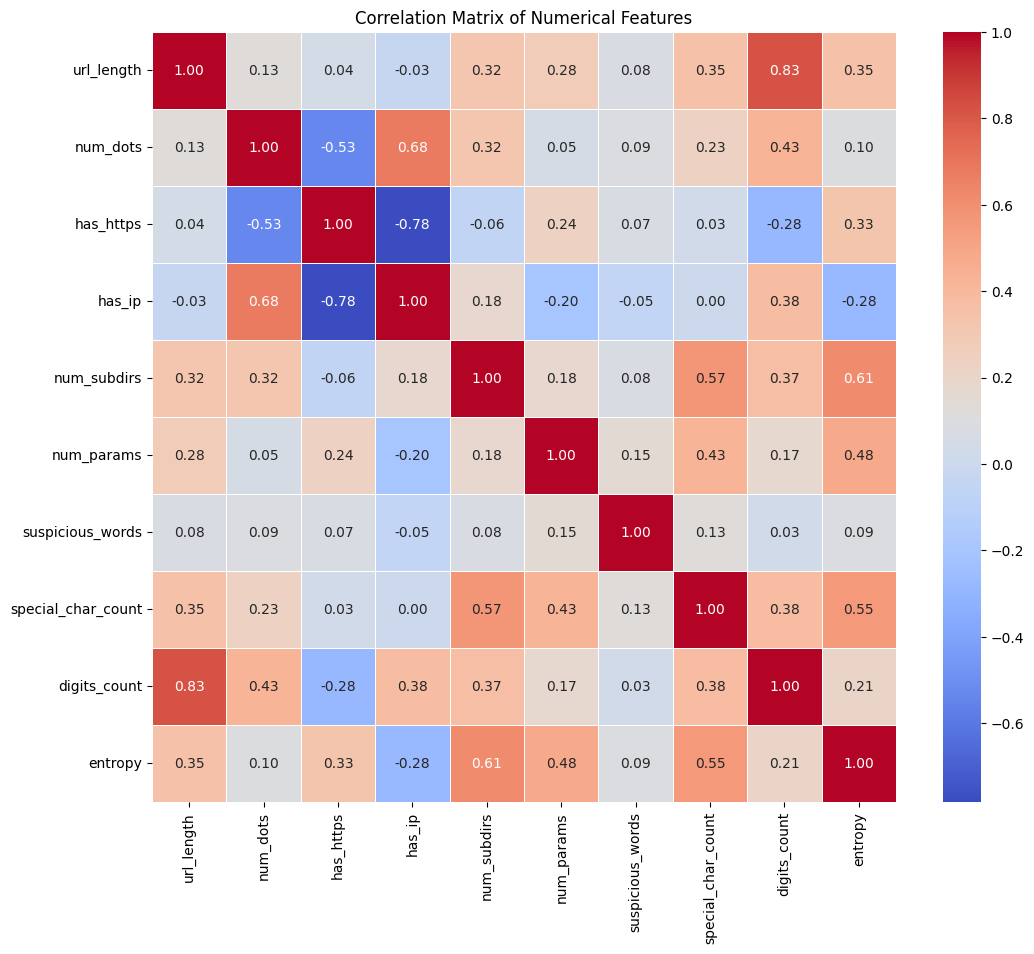

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for correlation analysis (excluding the target 'label' and non-numeric 'url', 'tld')
# We also exclude the temporary 'url_length_capped' if it exists and is not intended to replace 'url_length' yet
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove 'label' from numerical_cols as it's the target variable
if 'label' in numerical_cols:
    numerical_cols.remove('label')

# Remove 'url_length_capped' if it's a temporary column and 'url_length' is the one to analyze
if 'url_length_capped' in numerical_cols and 'url_length' in numerical_cols:
    # If we decided to keep url_length as the primary feature, remove the temporary capped one for this analysis
    numerical_cols.remove('url_length_capped')

print(f"Numerical columns for correlation analysis: {numerical_cols}")

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

This heatmap shows the Pearson correlation coefficient between each pair of numerical features. The values range from -1 to 1:

*   **1:** Perfect positive correlation (as one increases, the other increases proportionally).
*   **-1:** Perfect negative correlation (as one increases, the other decreases proportionally).
*   **0:** No linear correlation.

**How to interpret for feature selection:**

*   **Highly Positive or Negative Correlation (e.g., > 0.8 or < -0.8):** Features that are highly correlated (either positively or negatively) with each other might be redundant. Keeping only one of them could be sufficient, as they carry similar information. This helps reduce dimensionality and potential multicollinearity issues for some models.
*   **Low Correlation:** Features with low correlation among themselves are generally good, as they provide unique information.

Take a look at the heatmap. Are there any features that appear to be very highly correlated with each other? We can then decide if we want to remove one of them.

In [17]:
# Calculate the correlation of numerical features with the 'label' (target variable)
correlation_with_label = df[numerical_cols + ['label']].corr()['label'].sort_values(ascending=False)

print("Correlation of Numerical Features with 'label':")
print(correlation_with_label)



Correlation of Numerical Features with 'label':
label                 1.000000
num_subdirs           0.141735
entropy               0.133363
num_dots              0.125898
has_ip                0.069704
has_https             0.062848
digits_count          0.047991
url_length            0.028927
special_char_count    0.028911
num_params            0.016988
suspicious_words      0.008595
Name: label, dtype: float64


This output shows the Pearson correlation coefficient of each numerical feature with the `label` column.

*   **Positive correlation:** Features with a positive value mean that as the feature's value increases, the likelihood of the URL being a phishing site (label=1) tends to increase.
*   **Negative correlation:** Features with a negative value mean that as the feature's value increases, the likelihood of the URL being a phishing site tends to decrease.

`label` will always have a correlation of 1 with itself. We are interested in the other features.

Which features here show a strong correlation (either positive or negative) with the `label` that you think would be most indicative of a phishing URL?

In [18]:
# List of features to include in the new DataFrame
selected_features = [
    'url',
    'label',
    'tld',
    'num_subdirs',
    'entropy',
    'num_dots',
    'has_ip',
    'has_https',
    'digits_count',
    'url_length',
    'special_char_count'
]

# Create the new DataFrame with only the selected features
df_selected = df[selected_features].copy()

print("New DataFrame with selected features:")
display(df_selected.head())

New DataFrame with selected features:


,url,label,tld,num_subdirs,entropy,num_dots,has_ip,has_https,digits_count,url_length,special_char_count
0,http://forum.uk.securebankinggroup.com/107519/...,1,com,5,4.792985,3,0,0,29,89,4
1,http://b45042.com/fish/29,1,com,4,4.003856,1,0,0,7,25,0
2,http://bet73018.com/lottery/99,1,com,4,4.053236,1,0,0,7,30,0
3,https://logiin--metsa-autho.webflow.io/,1,io,3,4.150411,2,0,1,0,39,3
4,https://mettamasklogiiann.webflow.io/,1,io,3,4.100817,2,0,1,0,37,0


We now have a new DataFrame `df_selected` containing only the features we've chosen based on their correlation with the target variable, along with the original `url` and `tld` columns. This will be our working DataFrame moving forward.

Next, we can proceed with outlier detection and treatment on the numerical columns within this `df_selected` DataFrame, as previously discussed.

In [19]:
# Identify numerical columns in df_selected for outlier detection
numerical_cols_df_selected = df_selected.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude 'label' from outlier detection as it's the target variable
if 'label' in numerical_cols_df_selected:
    numerical_cols_df_selected.remove('label')

print(f"Numerical columns for outlier detection: {numerical_cols_df_selected}")

Numerical columns for outlier detection: ['num_subdirs', 'entropy', 'num_dots', 'has_ip', 'has_https', 'digits_count', 'url_length', 'special_char_count']


Now, let's detect and visualize outliers for these numerical columns using box plots and the Interquartile Range (IQR) method. We'll count the number of outliers for each feature.

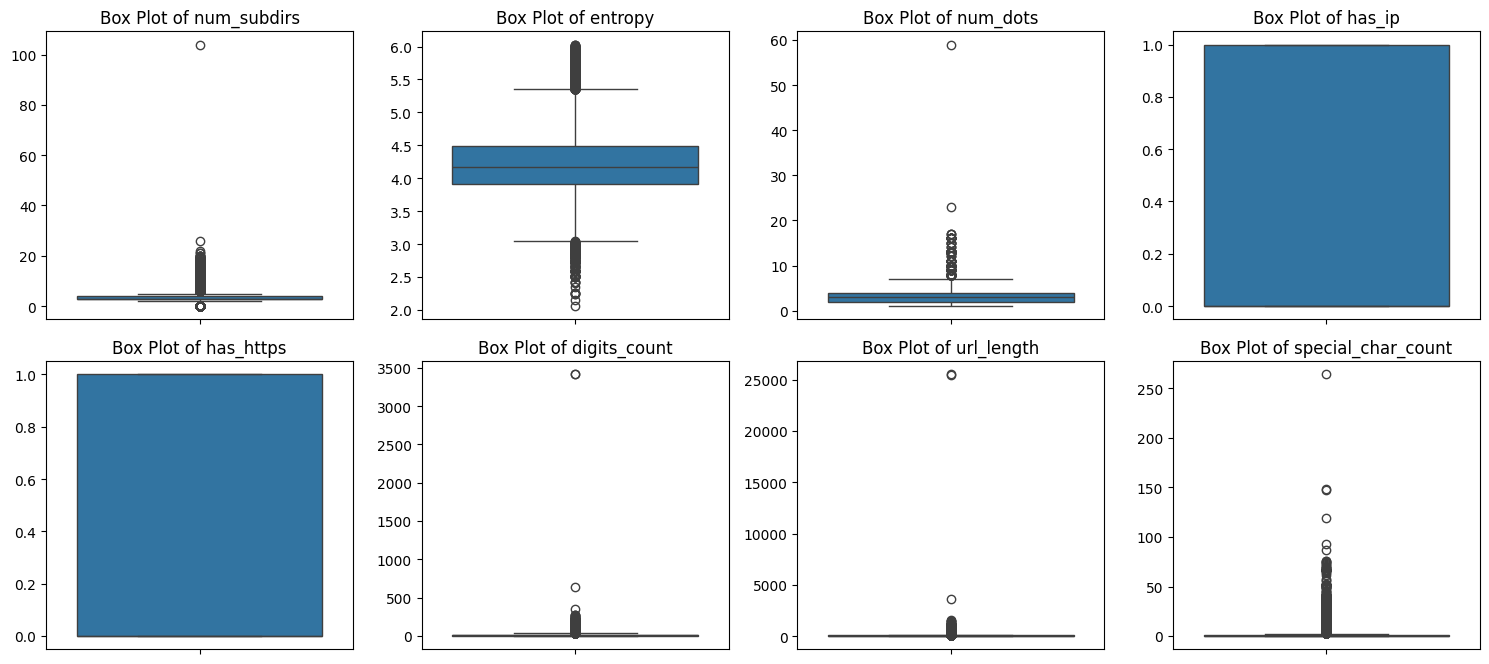


Number of outliers detected for each numerical feature (using IQR method):
num_subdirs: 30597
entropy: 6375
num_dots: 331
has_ip: 0
has_https: 0
digits_count: 7199
url_length: 12907
special_char_count: 25339


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

outlier_counts = {}

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_df_selected):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df_selected[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter

    # Calculate IQR for outlier detection
    Q1 = df_selected[col].quantile(0.25)
    Q3 = df_selected[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df_selected[(df_selected[col] < lower_bound) | (df_selected[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

plt.tight_layout()
plt.show()

print("\nNumber of outliers detected for each numerical feature (using IQR method):")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")

### Handling Outliers: Capping at 5th and 95th Percentiles

To address the identified outliers, we will apply capping to the numerical features. This involves setting any value below the 5th percentile to the 5th percentile value, and any value above the 95th percentile to the 95th percentile value. This method helps to reduce the impact of extreme values on our models without removing data points.

In [21]:
import numpy as np

df_capped = df_selected.copy()

print("Applying capping to numerical features at 5th and 95th percentiles...")

for col in numerical_cols_df_selected:
    if outlier_counts[col] > 0: # Only cap columns that had outliers identified
        lower_bound = df_capped[col].quantile(0.05)
        upper_bound = df_capped[col].quantile(0.95)

        df_capped[col] = np.clip(df_capped[col], lower_bound, upper_bound)
        print(f"  - Capped '{col}' between {lower_bound:.2f} and {upper_bound:.2f}")

print("Capping complete. Displaying first 5 rows of df_capped:")
display(df_capped.head())

Applying capping to numerical features at 5th and 95th percentiles...
  - Capped 'num_subdirs' between 3.00 and 8.00
  - Capped 'entropy' between 3.62 and 5.19
  - Capped 'num_dots' between 1.00 and 4.00
  - Capped 'digits_count' between 0.00 and 35.00
  - Capped 'url_length' between 22.00 and 155.00
  - Capped 'special_char_count' between 0.00 and 8.00
Capping complete. Displaying first 5 rows of df_capped:


,url,label,tld,num_subdirs,entropy,num_dots,has_ip,has_https,digits_count,url_length,special_char_count
0,http://forum.uk.securebankinggroup.com/107519/...,1,com,5,4.792985,3,0,0,29,89,4
1,http://b45042.com/fish/29,1,com,4,4.003856,1,0,0,7,25,0
2,http://bet73018.com/lottery/99,1,com,4,4.053236,1,0,0,7,30,0
3,https://logiin--metsa-autho.webflow.io/,1,io,3,4.150411,2,0,1,0,39,3
4,https://mettamasklogiiann.webflow.io/,1,io,3,4.100817,2,0,1,0,37,0


Now, let's visualize the numerical features again after capping to observe the effect on the outliers using box plots.

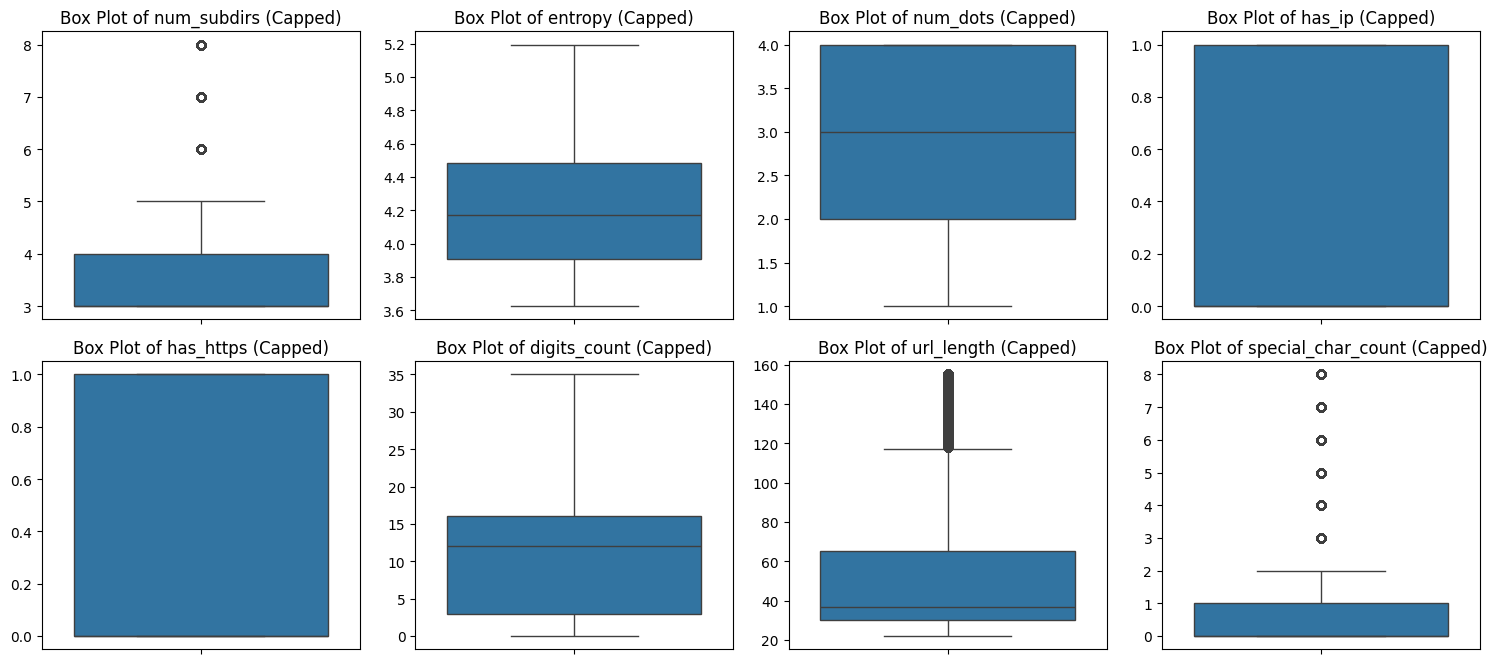


Number of outliers detected for each numerical feature AFTER CAPPING (using IQR method):
num_subdirs: 29777
entropy: 0
num_dots: 0
has_ip: 0
has_https: 0
digits_count: 0
url_length: 12907
special_char_count: 25339


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_counts_after_capping = {}

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_df_selected):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df_capped[col])
    plt.title(f'Box Plot of {col} (Capped)')
    plt.ylabel('') # Remove y-label to avoid clutter

    # Calculate IQR for outlier detection after capping
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers after capping
    outliers_after = df_capped[(df_capped[col] < lower_bound) | (df_capped[col] > upper_bound)]
    outlier_counts_after_capping[col] = len(outliers_after)

plt.tight_layout()
plt.show()

print("\nNumber of outliers detected for each numerical feature AFTER CAPPING (using IQR method):")
for col, count in outlier_counts_after_capping.items():
    print(f"{col}: {count}")

**Encoded Categorical Variable**

### Categorical Encoding for 'tld' Column
The 'tld' (Top-Level Domain) column is a categorical feature. To
prepare it for machine learning models, we need to convert it into a numerical format. We will use **One-Hot Encoding** for this, which creates new binary (0 or 1) columns for each unique category in 'tld'. This process transforms the single categorical column into multiple numerical columns, making it suitable for algorithms that require numerical input.

For example, if 'tld' has categories like 'com', 'org', 'net', one-hot encoding would create new columns such as `tld_com`, `tld_org`, and `tld_net`. A row with 'com' would have `tld_com` set to 1 and others to 0.

The `tld` column has now been successfully one-hot encoded, resulting in many new binary columns (e.g., `tld_com`, `tld_org`, etc.). Each of these new columns represents the presence or absence of a specific top-level domain. The `drop_first=True` argument helps to avoid multicollinearity by dropping the first category's column.

Now, our dataset (`df_encoded`) contains only numerical features, ready for model training. At this stage, all the identified preprocessing steps have been completed: missing values handled, duplicates checked, numerical features selected, outliers capped, and categorical features encoded.



In [23]:
import pandas as pd

# Perform one-hot encoding on the 'tld' column
df_encoded = pd.get_dummies(df_capped, columns=['tld'], prefix='tld', drop_first=True)

print("DataFrame after one-hot encoding 'tld' column:")
display(df_encoded.head())
print(f"Number of columns after encoding: {df_encoded.shape[1]}")

DataFrame after one-hot encoding 'tld' column:


,url,label,num_subdirs,entropy,num_dots,has_ip,has_https,digits_count,url_length,special_char_count,...,tld_wtf,tld_xin,tld_xn--p1ai,tld_xyz,tld_yachts,tld_za,tld_zip,tld_zm,tld_zone,tld_zw
0,http://forum.uk.securebankinggroup.com/107519/...,1,5,4.792985,3,0,0,29,89,4,...,False,False,False,False,False,False,False,False,False,False
1,http://b45042.com/fish/29,1,4,4.003856,1,0,0,7,25,0,...,False,False,False,False,False,False,False,False,False,False
2,http://bet73018.com/lottery/99,1,4,4.053236,1,0,0,7,30,0,...,False,False,False,False,False,False,False,False,False,False
3,https://logiin--metsa-autho.webflow.io/,1,3,4.150411,2,0,1,0,39,3,...,False,False,False,False,False,False,False,False,False,False
4,https://mettamasklogiiann.webflow.io/,1,3,4.100817,2,0,1,0,37,0,...,False,False,False,False,False,False,False,False,False,False


Number of columns after encoding: 545


### Feature Scaling and Normalization

Before training machine learning models, it's essential to scale and normalize the numerical features. This helps algorithms converge faster and prevents features with larger values from dominating the learning process.

We will perform the following steps:
1.  **Separate Features (X) and Target (y):** Define the independent variables (X) and the dependent variable (y).
2.  **Apply `StandardScaler`:** Standardize the numerical features by removing the mean and scaling to unit variance.

The `StandardScaler` plays a crucial role in preparing our data for machine learning models. Its primary purpose is to standardize features by transforming them to have a mean of 0 and a standard deviation of 1. Here's why this is important:

1.  **Prevents Dominance by Scale:** Some of our features, like `url_length` or `special_char_count`, might naturally have larger numerical ranges than others, such as `has_ip` (which is binary 0 or 1). Without scaling, features with larger values could disproportionately influence the model's objective function, making the model sensitive to their magnitude rather than their actual predictive power. `StandardScaler` ensures all features contribute equally, regardless of their original scale.

2.  **Improves Algorithm Performance:** Many machine learning algorithms, especially those that rely on distance calculations (like K-Nearest Neighbors, Support Vector Machines, or K-Means clustering) or gradient descent optimization (like neural networks and logistic regression), perform much better and converge faster when features are scaled. Unscaled data can lead to slower convergence or suboptimal solutions.

3.  **Addresses Outlier Impact (to an extent):** While we've already done some outlier capping, `StandardScaler` further normalizes the distribution. Although it's sensitive to outliers (as mean and standard deviation are affected by extreme values), it provides a consistent transformation across all features, which helps in consistent model performance.

In essence, `StandardScaler` makes sure that our model treats all features fairly, based on their information content rather than just their raw numerical size, leading to more robust and accurate models.

In [24]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
# We drop the 'url' column as it's a string and not a direct feature for modeling
# 'label' is our target variable
X = df_encoded.drop(columns=['url', 'label'])
y = df_encoded['label']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows of scaled features (X_scaled_df):")
display(X_scaled_df.head())

Features (X) shape: (160064, 543)
Target (y) shape: (160064,)

First 5 rows of scaled features (X_scaled_df):


,num_subdirs,entropy,num_dots,has_ip,has_https,digits_count,url_length,special_char_count,tld_0x31,tld_1,...,tld_wtf,tld_xin,tld_xn--p1ai,tld_xyz,tld_yachts,tld_za,tld_zip,tld_zm,tld_zone,tld_zw
0,0.574494,1.291244,0.051917,-0.971359,-0.875821,1.701762,1.044530,1.260577,-0.0025,-0.027505,...,-0.014576,-0.0025,-0.012246,-0.043406,-0.004329,-0.01581,-0.016393,-0.0025,-0.004329,-0.0025
1,-0.022901,-0.542863,-1.994883,-0.971359,-0.875821,-0.503188,-0.793211,-0.547814,-0.0025,-0.027505,...,-0.014576,-0.0025,-0.012246,-0.043406,-0.004329,-0.01581,-0.016393,-0.0025,-0.004329,-0.0025
2,-0.022901,-0.428093,-1.994883,-0.971359,-0.875821,-0.503188,-0.649637,-0.547814,-0.0025,-0.027505,...,-0.014576,-0.0025,-0.012246,-0.043406,-0.004329,-0.01581,-0.016393,-0.0025,-0.004329,-0.0025
3,-0.620296,-0.202238,-0.971483,-0.971359,1.141786,-1.204764,-0.391205,0.808479,-0.0025,-0.027505,...,-0.014576,-0.0025,-0.012246,-0.043406,-0.004329,-0.01581,-0.016393,-0.0025,-0.004329,-0.0025
4,-0.620296,-0.317505,-0.971483,-0.971359,1.141786,-1.204764,-0.448634,-0.547814,-0.0025,-0.027505,...,-0.014576,-0.0025,-0.012246,-0.043406,-0.004329,-0.01581,-0.016393,-0.0025,-0.004329,-0.0025


As you can see, the features in `X_scaled_df` now have a mean close to 0 and a standard deviation close to 1, effectively scaling them. This completes the feature scaling and normalization step.

# **Engineer Domain-Specific Features**


Domain-specific feature engineering is crucial because it allows us to create new features that directly capture expert knowledge about the problem. In this case, for phishing URL detection, features like hostname_length, num_hyphens, or num_at_symbol can be highly indicative of malicious intent.

These hand-crafted features often provide a machine learning model with richer and more direct signals than raw data alone, leading to improved predictive performance. They help the model understand subtle patterns and anomalies that might be missed if it only relies on basic features.
#We've added several new domain-specific features based on the URL structure, which can be highly indicative of phishing:

*   **`hostname_length`**: The length of the hostname. Phishing sites often use very long or complex hostnames to obscure the real domain.
*   **`path_length`**: The length of the path part of the URL. Unusual path lengths can sometimes indicate suspicious activity.
*   **`query_length`**: The length of the query string. Long or complex query strings might be used to embed malicious data or tracking parameters.
*   **`num_hyphens`**: The count of hyphens in the URL. Excessive hyphens can be used to make URLs appear legitimate or to confuse users.
*   **`num_at_symbol`**: The count of '@' symbols. The '@' symbol can be used in URLs to embed credentials or to mislead users about the actual domain by placing a legitimate-looking domain before the '@' and the real malicious domain after it (though browsers typically interpret the part after '@' as the host).
*   **`num_question_marks`**: The count of '?' symbols. This indicates the presence of query parameters. While normal, an unusual number could be suspicious.
*   **`num_ampersands`**: The count of '&' symbols. This indicates multiple parameters in the query string. Similar to question marks, an unusually high count could be a red flag.

In [25]:
import urllib.parse

# Create a copy to add new features without altering df_encoded directly yet
df_engineered = df_encoded.copy()

# Function to parse URL and extract components
def parse_url_features(url):
    parsed = urllib.parse.urlparse(url)
    return {
        'hostname_length': len(parsed.hostname) if parsed.hostname else 0,
        'path_length': len(parsed.path),
        'query_length': len(parsed.query),
        'num_hyphens': url.count('-'),
        'num_at_symbol': url.count('@'),
        'num_question_marks': url.count('?'),
        'num_ampersands': url.count('&')
    }

# Apply the function to the 'url' column and create new feature columns
url_features = df_engineered['url'].apply(parse_url_features).apply(pd.Series)
df_engineered = pd.concat([df_engineered, url_features], axis=1)

print("DataFrame with new engineered features:")
display(df_engineered.head())
print(f"Number of columns after engineering: {df_engineered.shape[1]}")

DataFrame with new engineered features:


,url,label,num_subdirs,entropy,num_dots,has_ip,has_https,digits_count,url_length,special_char_count,...,tld_zm,tld_zone,tld_zw,hostname_length,path_length,query_length,num_hyphens,num_at_symbol,num_question_marks,num_ampersands
0,http://forum.uk.securebankinggroup.com/107519/...,1,5,4.792985,3,0,0,29,89,4,...,False,False,False,31,51,0,4,0,0,0
1,http://b45042.com/fish/29,1,4,4.003856,1,0,0,7,25,0,...,False,False,False,10,8,0,0,0,0,0
2,http://bet73018.com/lottery/99,1,4,4.053236,1,0,0,7,30,0,...,False,False,False,12,11,0,0,0,0,0
3,https://logiin--metsa-autho.webflow.io/,1,3,4.150411,2,0,1,0,39,3,...,False,False,False,30,1,0,3,0,0,0
4,https://mettamasklogiiann.webflow.io/,1,3,4.100817,2,0,1,0,37,0,...,False,False,False,28,1,0,0,0,0,0


Number of columns after engineering: 552


In [26]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
# We drop the 'url' column as it's a string and not a direct feature for modeling
X_engineered = df_engineered.drop(columns=['url', 'label'])
y_engineered = df_engineered['label']

print("Original features (X_engineered) shape:", X_engineered.shape)
print("Original target (y_engineered) shape:", y_engineered.shape)

# First split: 70% for training, 30% for temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X_engineered, y_engineered, test_size=0.3, random_state=42, stratify=y_engineered)

# Second split: 50% of temp for validation, 50% for test (0.5 * 0.3 = 0.15 of original)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("\nDataset Split Shapes:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Original features (X_engineered) shape: (160064, 550)
Original target (y_engineered) shape: (160064,)

Dataset Split Shapes:
X_train shape: (112044, 550), y_train shape: (112044,)
X_val shape: (24010, 550), y_val shape: (24010,)
X_test shape: (24010, 550), y_test shape: (24010,)


The dataset has now been successfully split into training, validation, and test sets according to your specified proportions:

*   **Training Set (70%):** Used to train the machine learning models.
*   **Validation Set (15%):** Used to tune hyperparameters and evaluate model performance during the development phase.
*   **Test Set (15%):** Used for a final, unbiased evaluation of the chosen model's performance on unseen data.

Stratification was used during the splitting process to ensure that the proportion of classes (phishing vs. legitimate URLs) is maintained across all three datasets, which is important for balanced evaluation, especially with imbalanced datasets.

## Preprocessing Pipeline Documentation

This document outlines the steps taken to preprocess the phishing URL dataset, from initial loading to preparing it for machine learning model training and evaluation.

### 1. Data Loading and Initial Inspection
-   **Google Drive Mounting:** The Google Drive was mounted to access the dataset.
-   **Dataset Loading:** The `phishing_features.csv` dataset was loaded into a pandas DataFrame named `df`.
-   **Initial Checks:**
    -   `df.head()` was used to display the first few rows.
    -   `df.info()` was performed to get a summary of the DataFrame, including data types and non-null counts.
    -   Missing values were checked using `df.isnull().sum()`.

### 2. Missing Value Handling
-   The `tld` (Top-Level Domain) column, which had 821 missing values, was filled with the string `'unknown'` to ensure completeness and prevent data loss.

### 3. Duplicate Data Check
-   The dataset was checked for duplicate rows using `df.duplicated().sum()`. No duplicates were found.

### 4. Feature Selection (Based on Correlation)
-   **Correlation Analysis:**
    -   A correlation matrix was generated for all numerical features to identify highly correlated features among themselves using a heatmap.
    -   The Pearson correlation of each numerical feature with the target variable (`label`) was calculated and displayed.
-   **Feature Subset Creation:** A new DataFrame, `df_selected`, was created, retaining the `url`, `label`, `tld` columns, and numerical features with an absolute correlation coefficient greater than or equal to 0.02 with the `label`. These selected numerical features included: `num_subdirs`, `entropy`, `num_dots`, `has_ip`, `has_https`, `digits_count`, `url_length`, and `special_char_count`.

### 5. Outlier Handling
-   **Outlier Detection:** For the numerical columns in `df_selected`, outliers were detected using the Interquartile Range (IQR) method and visualized through box plots. Features like `num_subdirs`, `entropy`, `num_dots`, `digits_count`, `url_length`, and `special_char_count` were identified as having outliers.
-   **Outlier Treatment (Capping):** Outliers were treated by capping values at the **5th and 95th percentiles** for each affected numerical feature. This created a new DataFrame `df_capped`. Post-capping analysis showed a reduction in outliers for some features, though `num_subdirs`, `url_length`, and `special_char_count` still retained a notable number due to their underlying data distribution.

### 6. Categorical Encoding
-   **One-Hot Encoding:** The categorical `tld` column in `df_capped` was transformed using **one-hot encoding** (`pd.get_dummies`). This created new binary columns for each unique TLD, resulting in `df_encoded`. The `drop_first=True` parameter was used to prevent multicollinearity.

### 7. Feature Scaling and Normalization
-   **Separation of Features and Target:** The `df_encoded` DataFrame was split into features (`X`, excluding `url` and `label`) and the target variable (`y`, which is `label`).
-   **Standardization:** `StandardScaler` was applied to `X` to standardize the numerical features. This process transforms data to have a mean of 0 and a standard deviation of 1, which is crucial for optimizing many machine learning algorithms.

### 8. Domain-Specific Feature Engineering
-   **URL Feature Extraction:** Several new, domain-specific features were engineered from the original `url` column, including:
    -   `hostname_length`
    -   `path_length`
    -   `query_length`
    -   `num_hyphens`
    -   `num_at_symbol`
    -   `num_question_marks`
    -   `num_ampersands`
-   These features were added to the dataset, resulting in `df_engineered`, to provide more granular and indicative signals for phishing detection.

### 9. Dataset Splitting
-   **Train-Validation-Test Split:** The final `df_engineered` dataset was divided into training, validation, and test sets with a **70%-15%-15%** split ratio, respectively. Stratification was used to ensure that the class distribution of the target variable (`label`) is maintained across all three subsets.

In [27]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [28]:
# Initialize the models
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
rf = RandomForestClassifier(n_estimators=100, random_state=42)


In [29]:
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [30]:
svm.fit(X_train, y_train)


SVC(probability=True)

In [31]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Evaluate the *Models*

In [32]:
# Import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Function to evaluate the model
def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]

    print(f"\n{model.__class__.__name__}")
    print("Classification Report:")
    print(classification_report(y_val, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_val, y_prob))

# Evaluate all models
evaluate_model(lr, X_val, y_val)
evaluate_model(svm, X_val, y_val)
evaluate_model(rf, X_val, y_val)


LogisticRegression
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       123
           1       1.00      1.00      1.00     23887

    accuracy                           1.00     24010
   macro avg       1.00      1.00      1.00     24010
weighted avg       1.00      1.00      1.00     24010

Confusion Matrix:
[[  123     0]
 [    0 23887]]
ROC-AUC Score: 1.0

SVC
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       123
           1       1.00      1.00      1.00     23887

    accuracy                           1.00     24010
   macro avg       1.00      1.00      1.00     24010
weighted avg       1.00      1.00      1.00     24010

Confusion Matrix:
[[  123     0]
 [    0 23887]]
ROC-AUC Score: 1.0

RandomForestClassifier
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00    

# Compare the Models

In [33]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Store results in a dataframe
results = []

models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_val)
    results.append({
        "Model": name,
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, model.predict_proba(X_val)[:,1])
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression        1.0     1.0       1.0      1.0
1                  SVM        1.0     1.0       1.0      1.0
2        Random Forest        1.0     1.0       1.0      1.0


# Test the Best Model

In [34]:
# Test the best model (e.g., Random Forest)
y_test_pred = rf.predict(X_test)
y_test_prob = rf.predict_proba(X_test)[:,1]

# Evaluate test set performance
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("Test ROC-AUC Score:", roc_auc_score(y_test, y_test_prob))

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       123
           1       1.00      1.00      1.00     23887

    accuracy                           1.00     24010
   macro avg       1.00      1.00      1.00     24010
weighted avg       1.00      1.00      1.00     24010

Test Confusion Matrix:
[[  123     0]
 [    0 23887]]
Test ROC-AUC Score: 1.0
